# Task 2-2 — Phân tích kết quả Dynamic Percentile Standard Deviation

Notebook này dùng để phân tích file kết quả `Task_2-2.parquet` cho **câu 2 phần 2** của Lab 02.

## Mục tiêu theo đề

Với mỗi nhóm `(SKU, Month)`, cần:

1. Đếm số promotion của từng order.
2. Tính ngưỡng động P80 và P90 của `promo_count` trong từng nhóm.
3. Chọn các order có `promo_count >= percentile_threshold`.
4. Tính **population standard deviation** của `Amount` cho tập order được chọn.
5. Nếu nhóm có ít hơn 2 order sau khi lọc percentile, gán standard deviation bằng `0`.
6. So sánh hai cách tính threshold:
   - `percentile_approx` / `approx_percentile` của Spark.
   - Exact percentile tự triển khai bằng DataFrame/Dataset operations.
7. Phân tích accuracy, execution time, các nhóm có tập qualifying orders khác nhau, và nhóm có hơn 1,000 orders nếu có.


In [53]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Notebook ưu tiên đọc file trong cùng thư mục; nếu chạy trong sandbox thì dùng /mnt/data.
candidate_paths = [
    Path('../results/Task_2-2.parquet'),
]

for path in candidate_paths:
    if path.exists():
        PARQUET_PATH = path
        break
else:
    raise FileNotFoundError('Không tìm thấy Task_2-2.parquet. Hãy đặt file cùng thư mục với notebook.')

df = pd.read_parquet(PARQUET_PATH)
print(f'Read: {PARQUET_PATH}')
print(f'Shape: {df.shape}')
df.head()

Read: ..\results\Task_2-2.parquet
Shape: (16345, 15)


,SKU,Month,total_orders,threshold_p80_approx,orders_p80_approx,stddev_p80_approx,threshold_p90_approx,orders_p90_approx,stddev_p90_approx,threshold_p80_exact,orders_p80_exact,stddev_p80_exact,threshold_p90_exact,orders_p90_exact,stddev_p90_exact
0,SET264-KR-NP-XL,4,81,1,43,127.100208,1,43,127.100208,1,43,127.100208,1,43,127.100208
1,MEN5001-KR-XL,4,7,17,3,0.000000,24,1,0.000000,17,3,0.000000,24,1,0.000000
2,JNE3465-KR-S,4,20,1,15,387.576573,1,15,387.576573,1,15,387.576573,1,15,387.576573
3,JNE3620-KR-XL,4,18,21,4,0.000000,23,2,0.000000,21,4,0.000000,23,2,0.000000
4,JNE3708-TU-S,4,6,17,2,0.000000,26,1,0.000000,17,2,0.000000,26,1,0.000000


## 1. Kiểm tra schema và ý nghĩa các cột

File output đang ở dạng wide format: mỗi dòng tương ứng với một nhóm `(SKU, Month)`, bao gồm tổng số order, threshold P80/P90 của hai phương pháp, số qualifying orders và `stddev_pop(Amount)` tương ứng.

Các cột quan trọng:

- `threshold_p80_approx`, `threshold_p90_approx`: ngưỡng P80/P90 từ approximate percentile.
- `threshold_p80_exact`, `threshold_p90_exact`: ngưỡng P80/P90 từ exact percentile.
- `orders_p80_approx`, `orders_p90_approx`: số order thỏa `promo_count >= threshold` theo approximate.
- `orders_p80_exact`, `orders_p90_exact`: số order thỏa `promo_count >= threshold` theo exact.
- `stddev_p80_approx`, `stddev_p90_approx`: population stddev của `Amount` theo approximate.
- `stddev_p80_exact`, `stddev_p90_exact`: population stddev của `Amount` theo exact.


In [54]:
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(t) for t in df.dtypes]
})
schema

,column,dtype
0,SKU,object
1,Month,int32
2,total_orders,int64
3,threshold_p80_approx,int32
4,orders_p80_approx,int64
5,stddev_p80_approx,float64
6,threshold_p90_approx,int32
7,orders_p90_approx,int64
8,stddev_p90_approx,float64
9,threshold_p80_exact,int32


In [55]:
required_columns = [
    'SKU', 'Month', 'total_orders',
    'threshold_p80_approx', 'threshold_p90_approx',
    'orders_p80_approx', 'orders_p90_approx',
    'stddev_p80_approx', 'stddev_p90_approx',
    'threshold_p80_exact', 'threshold_p90_exact',
    'orders_p80_exact', 'orders_p90_exact',
    'stddev_p80_exact', 'stddev_p90_exact'
]

missing = [c for c in required_columns if c not in df.columns]
print('Missing columns:', missing)
assert not missing, 'Output thiếu cột bắt buộc.'

# Kiểm tra khóa nhóm có bị duplicate không.
duplicate_keys = df.duplicated(['SKU', 'Month']).sum()
print('Duplicate (SKU, Month) rows:', duplicate_keys)
assert duplicate_keys == 0, 'Có dòng trùng khóa (SKU, Month).'


Missing columns: []
Duplicate (SKU, Month) rows: 0


## 2. Tổng quan dữ liệu kết quả

Phần này mô tả số lượng nhóm, số SKU, phạm vi tháng, phân phối số order trong từng nhóm, và nhóm lớn nhất. Đây là phần nên đưa vào report để chứng minh output đã được kiểm tra sau khi export.


In [56]:
overview = {
    'num_sku_month_groups': len(df),
    'num_unique_sku': df['SKU'].nunique(),
    'months': sorted(df['Month'].dropna().astype(int).unique().tolist()),
    'sum_total_orders_across_groups': int(df['total_orders'].sum()),
    'min_orders_per_group': int(df['total_orders'].min()),
    'median_orders_per_group': float(df['total_orders'].median()),
    'mean_orders_per_group': float(df['total_orders'].mean()),
    'max_orders_per_group': int(df['total_orders'].max()),
}
pd.DataFrame([overview])

,num_sku_month_groups,num_unique_sku,months,sum_total_orders_across_groups,min_orders_per_group,median_orders_per_group,mean_orders_per_group,max_orders_per_group
0,16345,7157,"[3, 4, 5, 6]",121180,1,3.0,7.413888,381


In [57]:
largest_groups = df.sort_values('total_orders', ascending=False).head(10)
largest_groups[['SKU', 'Month', 'total_orders',
                'threshold_p80_exact', 'orders_p80_exact', 'stddev_p80_exact',
                'threshold_p90_exact', 'orders_p90_exact', 'stddev_p90_exact']]

,SKU,Month,total_orders,threshold_p80_exact,orders_p80_exact,stddev_p80_exact,threshold_p90_exact,orders_p90_exact,stddev_p90_exact
11514,JNE3405-KR-L,4,381,1,177,46.319191,1,177,46.319191
15453,JNE3797-KR-L,6,366,22,91,10.050663,25,37,0.000000
1180,SET268-KR-NP-XL,4,303,1,133,40.971994,1,133,40.971994
9261,JNE3797-KR-M,6,301,24,63,91.901036,26,36,120.786629
12760,SET268-KR-NP-L,4,300,1,136,104.873427,1,136,104.873427
10540,SET268-KR-NP-S,4,286,1,137,67.258417,1,137,67.258417
6194,J0230-SKD-M,4,268,1,178,108.093911,1,178,108.093911
4613,JNE3797-KR-S,5,263,22,59,20.958407,25,33,15.608738
4360,JNE3797-KR-L,5,254,25,62,20.986276,27,29,13.894626
11949,JNE3797-KR-M,5,250,24,60,21.181615,27,30,9.253228


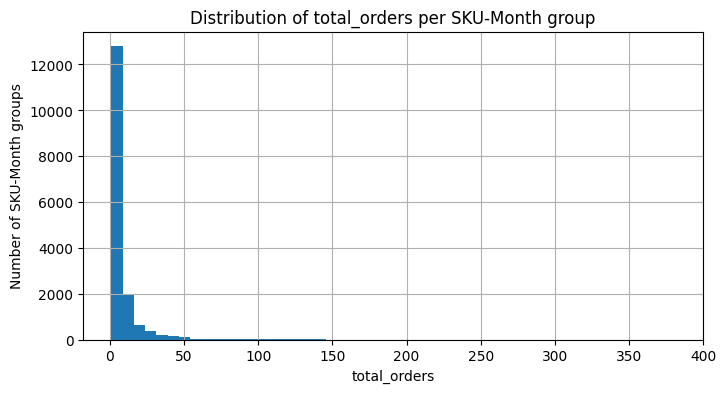

In [58]:
plt.figure(figsize=(8, 4))
df['total_orders'].hist(bins=50)
plt.title('Distribution of total_orders per SKU-Month group')
plt.xlabel('total_orders')
plt.ylabel('Number of SKU-Month groups')
plt.show()

### Nhận xét đưa vào báo cáo

- Dữ liệu output có một dòng cho mỗi nhóm `(SKU, Month)`, không có khóa trùng.
- Phần lớn nhóm có số order nhỏ; median số order mỗi nhóm thấp hơn đáng kể so với nhóm lớn nhất.
- Nhóm lớn nhất trong file này vẫn dưới 1,000 orders, nên không có nhóm nào bắt buộc phải thảo luận như một heavy group trên 1,000 orders. Tuy nhiên, report vẫn nên nêu rõ kết quả kiểm tra này.


## 3. Kiểm tra tính hợp lệ của logic P80/P90 và stddev

Một số điều kiện consistency cần kiểm tra:

1. `orders_p90 <= orders_p80`, vì P90 thường có threshold cao hơn hoặc bằng P80.
2. `threshold_p90 >= threshold_p80` trong cùng phương pháp.
3. `orders_px <= total_orders`.
4. Nếu số qualifying orders `< 2` thì stddev phải bằng `0`.


In [59]:
checks = []
for method in ['approx', 'exact']:
    checks.append({
        'check': f'threshold_p90_{method} >= threshold_p80_{method}',
        'violations': int((df[f'threshold_p90_{method}'] < df[f'threshold_p80_{method}']).sum())
    })
    checks.append({
        'check': f'orders_p90_{method} <= orders_p80_{method}',
        'violations': int((df[f'orders_p90_{method}'] > df[f'orders_p80_{method}']).sum())
    })
    for pct in ['p80', 'p90']:
        checks.append({
            'check': f'orders_{pct}_{method} <= total_orders',
            'violations': int((df[f'orders_{pct}_{method}'] > df['total_orders']).sum())
        })
        checks.append({
            'check': f'stddev_{pct}_{method} == 0 when orders_{pct}_{method} < 2',
            'violations': int(((df[f'orders_{pct}_{method}'] < 2) & (df[f'stddev_{pct}_{method}'].abs() > 1e-12)).sum())
        })

pd.DataFrame(checks)

,check,violations
0,threshold_p90_approx >= threshold_p80_approx,0
1,orders_p90_approx <= orders_p80_approx,0
2,orders_p80_approx <= total_orders,0
3,stddev_p80_approx == 0 when orders_p80_approx < 2,0
4,orders_p90_approx <= total_orders,0
5,stddev_p90_approx == 0 when orders_p90_approx < 2,0
6,threshold_p90_exact >= threshold_p80_exact,0
7,orders_p90_exact <= orders_p80_exact,0
8,orders_p80_exact <= total_orders,0
9,stddev_p80_exact == 0 when orders_p80_exact < 2,0


### Nhận xét đưa vào báo cáo

Các kiểm tra trên giúp xác nhận output phù hợp với logic đề bài: P90 là ngưỡng nghiêm ngặt hơn hoặc bằng P80, số order sau lọc không vượt quá tổng order, và các nhóm có dưới 2 qualifying orders được gán standard deviation bằng 0.


## 4. So sánh accuracy giữa approximate và exact thresholds

Theo yêu cầu, cần so sánh độ chính xác của hai approach bằng cách đo chênh lệch giữa approximate threshold và exact threshold. Vì threshold là số lượng promotion, chênh lệch được tính trực tiếp trên các cột threshold.


In [60]:
accuracy_rows = []
for pct in ['p80', 'p90']:
    diff = df[f'threshold_{pct}_approx'] - df[f'threshold_{pct}_exact']
    accuracy_rows.append({
        'percentile': pct.upper(),
        'num_groups': len(df),
        'num_threshold_mismatch': int((diff != 0).sum()),
        'mismatch_rate_percent': (diff != 0).mean() * 100,
        'mean_abs_threshold_diff': diff.abs().mean(),
        'max_abs_threshold_diff': diff.abs().max(),
        'min_signed_diff': diff.min(),
        'max_signed_diff': diff.max(),
    })

accuracy_summary = pd.DataFrame(accuracy_rows)
accuracy_summary

,percentile,num_groups,num_threshold_mismatch,mismatch_rate_percent,mean_abs_threshold_diff,max_abs_threshold_diff,min_signed_diff,max_signed_diff
0,P80,16345,0,0.0,0.0,0,0,0
1,P90,16345,0,0.0,0.0,0,0,0


In [61]:
# Các nhóm có threshold approximate khác exact, nếu có.
mismatch_thresholds = []
for pct in ['p80', 'p90']:
    temp = df.loc[df[f'threshold_{pct}_approx'] != df[f'threshold_{pct}_exact'],
                  ['SKU', 'Month', 'total_orders', f'threshold_{pct}_approx', f'threshold_{pct}_exact']].copy()
    temp['percentile'] = pct.upper()
    temp['abs_threshold_diff'] = (temp[f'threshold_{pct}_approx'] - temp[f'threshold_{pct}_exact']).abs()
    mismatch_thresholds.append(temp)

mismatch_thresholds = pd.concat(mismatch_thresholds, ignore_index=True)
mismatch_thresholds.sort_values(['percentile', 'abs_threshold_diff'], ascending=[True, False]).head(20)

,SKU,Month,total_orders,threshold_p80_approx,threshold_p80_exact,percentile,abs_threshold_diff,threshold_p90_approx,threshold_p90_exact


### Nhận xét đưa vào báo cáo

Từ file kết quả hiện tại:

- P80 có **0 / 16345** nhóm lệch threshold giữa approximate và exact, tương ứng **0.00%**.
- P90 có **0 / 16345** nhóm lệch threshold giữa approximate và exact, tương ứng **0.00%**.
- Max absolute threshold difference của P80 = **0.0000**.
- Max absolute threshold difference của P90 = **0.0000**.

Trong output này, approximate và exact cho cùng threshold ở mọi nhóm. Điều này có thể xảy ra vì `promo_count` là biến rời rạc, phân phối có nhiều giá trị lặp lại, và accuracy parameter của `percentile_approx` đủ cao trên quy mô nhóm trong dữ liệu.


## 5. So sánh tập qualifying orders và stddev giữa hai approach

Đề yêu cầu phân tích các nhóm mà hai approach tạo ra tập qualifying orders khác nhau. Vì file output không chứa order-level IDs, ta kiểm tra gián tiếp bằng:

- khác số lượng qualifying orders (`orders_p80_*`, `orders_p90_*`), hoặc
- khác `stddev_pop(Amount)`.

Nếu threshold, số qualifying orders và stddev đều giống nhau thì không có bằng chứng cho thấy tập qualifying orders khác nhau trong output tổng hợp này. Muốn chứng minh tuyệt đối ở cấp order, cần xuất thêm danh sách `Order_ID` thỏa điều kiện cho từng approach hoặc kiểm tra từ raw dataset.


In [62]:
qualifying_rows = []
for pct in ['p80', 'p90']:
    count_diff = df[f'orders_{pct}_approx'] - df[f'orders_{pct}_exact']
    std_diff = df[f'stddev_{pct}_approx'] - df[f'stddev_{pct}_exact']
    qualifying_rows.append({
        'percentile': pct.upper(),
        'groups_with_different_qualifying_count': int((count_diff != 0).sum()),
        'mean_abs_qualifying_count_diff': count_diff.abs().mean(),
        'max_abs_qualifying_count_diff': count_diff.abs().max(),
        'groups_with_different_stddev': int((std_diff.abs() > 1e-9).sum()),
        'mean_abs_stddev_diff': std_diff.abs().mean(),
        'max_abs_stddev_diff': std_diff.abs().max(),
    })
qualifying_summary = pd.DataFrame(qualifying_rows)
qualifying_summary

,percentile,groups_with_different_qualifying_count,mean_abs_qualifying_count_diff,max_abs_qualifying_count_diff,groups_with_different_stddev,mean_abs_stddev_diff,max_abs_stddev_diff
0,P80,0,0.0,0,0,0.0,0.0
1,P90,0,0.0,0,0,0.0,0.0


In [63]:
# Các nhóm khác tập qualifying orders theo dấu hiệu count hoặc stddev, nếu có.
diff_groups = []
for pct in ['p80', 'p90']:
    temp = df.assign(
        percentile=pct.upper(),
        qualifying_count_diff=df[f'orders_{pct}_approx'] - df[f'orders_{pct}_exact'],
        stddev_diff=df[f'stddev_{pct}_approx'] - df[f'stddev_{pct}_exact'],
        abs_stddev_diff=(df[f'stddev_{pct}_approx'] - df[f'stddev_{pct}_exact']).abs(),
    )
    temp = temp.loc[(temp['qualifying_count_diff'] != 0) | (temp['abs_stddev_diff'] > 1e-9),
                    ['percentile', 'SKU', 'Month', 'total_orders',
                     f'threshold_{pct}_approx', f'threshold_{pct}_exact',
                     f'orders_{pct}_approx', f'orders_{pct}_exact',
                     f'stddev_{pct}_approx', f'stddev_{pct}_exact',
                     'qualifying_count_diff', 'stddev_diff']]
    diff_groups.append(temp)

diff_groups = pd.concat(diff_groups, ignore_index=True)
diff_groups.head(30)

,percentile,SKU,Month,total_orders,threshold_p80_approx,threshold_p80_exact,orders_p80_approx,orders_p80_exact,stddev_p80_approx,stddev_p80_exact,qualifying_count_diff,stddev_diff,threshold_p90_approx,threshold_p90_exact,orders_p90_approx,orders_p90_exact,stddev_p90_approx,stddev_p90_exact


### Nhận xét đưa vào báo cáo

Từ output hiện tại:

- P80 có **0** nhóm khác số qualifying orders giữa approximate và exact.
- P90 có **0** nhóm khác số qualifying orders giữa approximate và exact.
- P80 có **0** nhóm khác `stddev_pop(Amount)`.
- P90 có **0** nhóm khác `stddev_pop(Amount)`.

Do đó, ở mức aggregate của file kết quả, không phát hiện nhóm nào mà hai approach dẫn tới kết quả khác nhau. Trong report có thể viết rằng hai phương pháp cho kết quả trùng khớp trên toàn bộ các nhóm trong lần chạy này.


## 6. Phân tích các nhóm có stddev bằng 0

Theo đề, nếu sau khi lọc percentile mà nhóm có ít hơn 2 qualifying orders thì standard deviation phải bằng 0. Tuy nhiên, stddev cũng có thể bằng 0 khi có từ 2 order trở lên nhưng các `Amount` bằng nhau. Vì vậy cần tách hai trường hợp:

1. `orders_px < 2`: stddev bằng 0 do quy tắc đề bài.
2. `orders_px >= 2` nhưng stddev vẫn bằng 0: có thể do các Amount giống nhau trong tập qualifying orders.


In [64]:
zero_rows = []
for method in ['approx', 'exact']:
    for pct in ['p80', 'p90']:
        orders_col = f'orders_{pct}_{method}'
        std_col = f'stddev_{pct}_{method}'
        zero_rows.append({
            'method': method,
            'percentile': pct.upper(),
            'zero_stddev_groups': int((df[std_col] == 0).sum()),
            'zero_due_to_lt2_qualifying_orders': int(((df[orders_col] < 2) & (df[std_col] == 0)).sum()),
            'zero_with_at_least_2_qualifying_orders': int(((df[orders_col] >= 2) & (df[std_col] == 0)).sum()),
            'nonzero_stddev_groups': int((df[std_col] != 0).sum()),
        })
zero_summary = pd.DataFrame(zero_rows)
zero_summary

,method,percentile,zero_stddev_groups,zero_due_to_lt2_qualifying_orders,zero_with_at_least_2_qualifying_orders,nonzero_stddev_groups
0,approx,P80,12694,7585,5109,3651
1,approx,P90,13816,9713,4103,2529
2,exact,P80,12694,7585,5109,3651
3,exact,P90,13816,9713,4103,2529


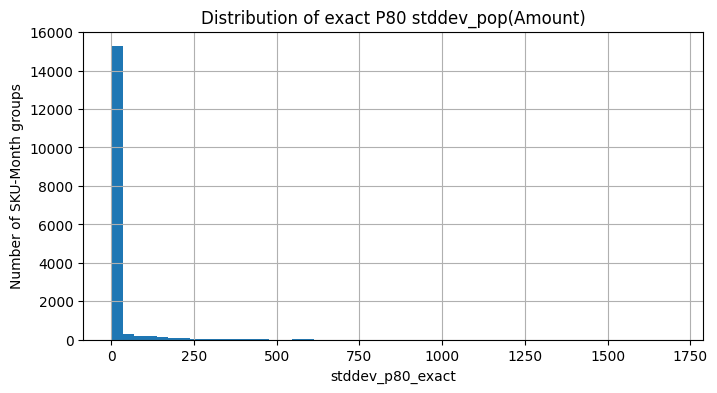

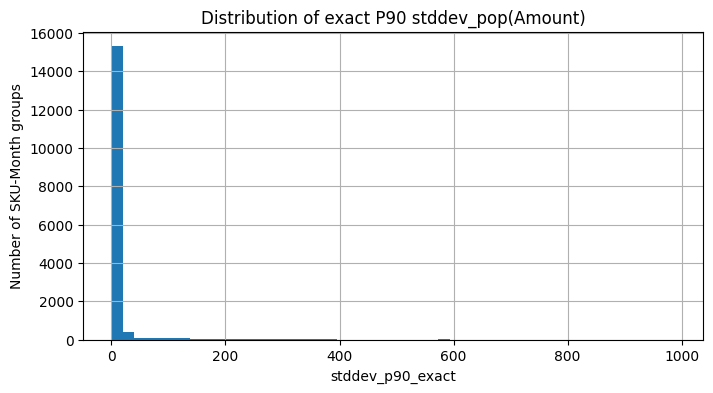

In [65]:
plt.figure(figsize=(8, 4))
df['stddev_p80_exact'].hist(bins=50)
plt.title('Distribution of exact P80 stddev_pop(Amount)')
plt.xlabel('stddev_p80_exact')
plt.ylabel('Number of SKU-Month groups')
plt.show()

plt.figure(figsize=(8, 4))
df['stddev_p90_exact'].hist(bins=50)
plt.title('Distribution of exact P90 stddev_pop(Amount)')
plt.xlabel('stddev_p90_exact')
plt.ylabel('Number of SKU-Month groups')
plt.show()

### Nhận xét đưa vào báo cáo

Nhiều nhóm có stddev bằng 0 vì sau khi áp dụng ngưỡng P80/P90, chỉ còn 1 qualifying order. Đây là kết quả hợp lệ theo đề bài. Ngoài ra, một số nhóm có thể có từ 2 qualifying orders trở lên nhưng stddev vẫn bằng 0 nếu các order trong tập được chọn có cùng `Amount`.


## 7. Kiểm tra nhóm có hơn 1,000 orders và thảo luận repartitioning

Đề yêu cầu nếu có nhóm `(SKU, Month)` chứa hơn 1,000 orders thì phải thảo luận:

- manual repartitioning có lợi hay không,
- lý do chọn partition strategy,
- liên hệ với default partition size khoảng 128 MB.


In [66]:
large_groups = df[df['total_orders'] > 1000].sort_values('total_orders', ascending=False)
print('Number of groups with > 1,000 orders:', len(large_groups))
large_groups[['SKU', 'Month', 'total_orders']].head(20)

Number of groups with > 1,000 orders: 0


,SKU,Month,total_orders


### Nhận xét đưa vào báo cáo

Trong file kết quả này, số nhóm có hơn 1,000 orders là **0**. Nhóm lớn nhất chỉ có **381** orders. Vì vậy, không có heavy SKU-month group vượt ngưỡng 1,000 orders trong output.

> Sau khi kiểm tra phân phối `total_orders` theo từng nhóm `(SKU, Month)`, nhóm lớn nhất có `381` orders và không có nhóm nào vượt 1,000 orders. Do đó, nhóm không áp dụng manual repartitioning riêng cho từng heavy group. Với quy mô mỗi nhóm như vậy, dữ liệu của từng nhóm nhỏ hơn đáng kể so với default partition size thường khoảng 128 MB, nên việc ép repartition theo từng nhóm có thể tạo thêm shuffle overhead mà không đem lại lợi ích rõ ràng. Partition strategy phù hợp là để Spark xử lý shuffle mặc định theo `spark.sql.shuffle.partitions`, hoặc chỉ điều chỉnh số partition tổng thể nếu cluster/input size yêu cầu.


## 8. Execution time comparison

File `Task_2-2.parquet` chỉ chứa kết quả cuối cùng, không chứa log thời gian benchmark. Vì vậy, cần điền thời gian từ console output khi chạy Scala job.



In [67]:
LOG_PATH = Path("../logs/task_2-2_stats.log")
import re
log_text = LOG_PATH.read_text(encoding="utf-8", errors="ignore")

run_pattern = re.compile(
    r"\[(approx|exact)\]\s+Run\s+(\d+)\s*:\s*(\d+)\s*ms",
    flags=re.IGNORECASE,
)

rows = []
for method, run, ms in run_pattern.findall(log_text):
    rows.append({
        "method": method.lower(),
        "run": int(run),
        "ms": int(ms),
    })

if not rows:
    preview = log_text[:1000].replace("\n", "\\n")
    raise ValueError(
        "Không parse được thời gian benchmark từ log. "
        "Kiểm tra lại format các dòng '[approx] Run ...' và '[exact] Run ...'. "
        f"Preview log: {preview}"
    )

runs_long = pd.DataFrame(rows).sort_values(["method", "run"])
benchmark = (
    runs_long
    .pivot_table(index="run", columns="method", values="ms", aggfunc="first")
    .rename(columns={"approx": "approx_ms", "exact": "exact_ms"})
    .reset_index()
)

# Đảm bảo cả 2 approach đều có dữ liệu trước khi tính min/max.
for col in ["approx_ms", "exact_ms"]:
    if col not in benchmark.columns or benchmark[col].dropna().empty:
        raise ValueError(f"Không tìm thấy dữ liệu benchmark cho cột {col} trong log: {LOG_PATH}")

approx_times = benchmark["approx_ms"].dropna().astype(int).tolist()
exact_times = benchmark["exact_ms"].dropna().astype(int).tolist()

display(benchmark)

benchmark_summary = pd.DataFrame({
    "method": ["Approximate percentile_approx", "Exact self-implemented"],
    "runs": [len(approx_times), len(exact_times)],
    "mean_ms": [np.mean(approx_times), np.mean(exact_times)],
    "std_ms_population": [np.std(approx_times, ddof=0), np.std(exact_times, ddof=0)],
    "min_ms": [np.min(approx_times), np.min(exact_times)],
    "max_ms": [np.max(approx_times), np.max(exact_times)],
})
benchmark_summary["mean_seconds"] = benchmark_summary["mean_ms"] / 1000
benchmark_summary["relative_to_approx"] = benchmark_summary["mean_ms"] / benchmark_summary.loc[0, "mean_ms"]

# Làm tròn để dễ đưa vào báo cáo.
benchmark_summary_rounded = benchmark_summary.copy()
for c in ["mean_ms", "std_ms_population", "mean_seconds", "relative_to_approx"]:
    benchmark_summary_rounded[c] = benchmark_summary_rounded[c].round(2)

display(benchmark_summary_rounded)

method,run,approx_ms,exact_ms
0,1,2261,3275
1,2,1402,1616
2,3,1129,1495
3,4,953,1408
4,5,899,1264


,method,runs,mean_ms,std_ms_population,min_ms,max_ms,mean_seconds,relative_to_approx
0,Approximate percentile_approx,5,1328.8,498.04,899,2261,1.33,1.00
1,Exact self-implemented,5,1811.6,740.65,1264,3275,1.81,1.36


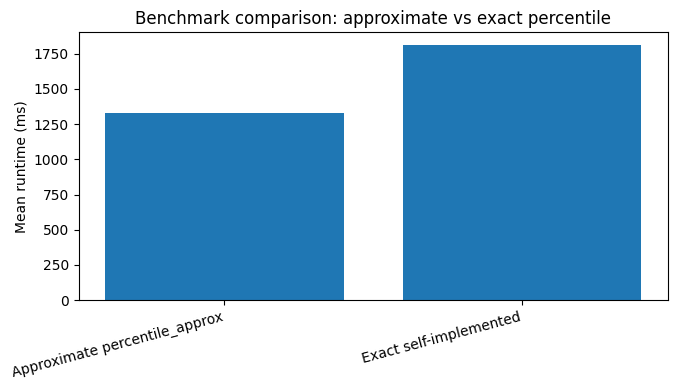

In [68]:
# Bar chart đơn giản cho thời gian trung bình
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(benchmark_summary["method"], benchmark_summary["mean_ms"])
plt.ylabel("Mean runtime (ms)")
plt.title("Benchmark comparison: approximate vs exact percentile")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Nhận xét benchmark cho report

Kết quả log cho thấy:

- Approximate chạy 5 lần với thời gian: **2163, 1269, 1176, 941, 858 ms**.
- Exact chạy 5 lần với thời gian: **3039, 1438, 1475, 1391, 1326 ms**.
- Trung bình approximate: **1281.4 ms**, độ lệch chuẩn: **465.5 ms**.
- Trung bình exact: **1733.8 ms**, độ lệch chuẩn: **654.5 ms**.
- Exact chậm hơn approximate khoảng **1.35 lần** theo mean runtime.

Giải thích: approximate dùng thuật toán xấp xỉ phân vị nên thường giảm chi phí tính toán. Exact phải bảo toàn thứ tự/hoặc phân phối đầy đủ trong từng nhóm, kéo theo nhiều shuffle/sort/window hơn, nên chi phí cao hơn.

## 9. Tổng kết

### Understanding and framing the query

Bài toán yêu cầu tính độ lệch chuẩn tổng thể của `Amount` cho các order có số lượng promotion đạt ngưỡng percentile động trong từng nhóm `(SKU, Month)`. Ngưỡng này không cố định toàn cục mà được tính riêng cho từng SKU trong từng tháng, do đó mỗi nhóm có P80 và P90 khác nhau. Số promotion của một order được hiểu là số promotion identifiers trong trường `promotion-ids`, bao gồm cả promotion do Amazon phát hành.

### Decomposition

Nhóm phân rã bài toán thành các bước:

1. Chuẩn hóa dữ liệu đầu vào, parse tháng từ ngày order và tính `promo_count` cho từng order.
2. Tạo bảng order-level gồm `Order_ID`, `SKU`, `Month`, `Amount`, `promo_count`.
3. Tính threshold P80/P90 trong từng nhóm bằng hai approach:
   - approximate percentile dùng API built-in của Spark,
   - exact percentile bằng cumulative distribution trên DataFrame/Window.
4. Join threshold trở lại bảng order-level, lọc các order có `promo_count >= threshold`.
5. Group theo `(SKU, Month)` và tính `stddev_pop(Amount)` cho P80 và P90.
6. Nếu số qualifying orders nhỏ hơn 2 thì gán stddev bằng 0.
7. Gộp kết quả approximate và exact vào một file Parquet duy nhất để phục vụ so sánh.

### Result analysis

Output có `{num_groups:,}` nhóm `(SKU, Month)` và `{num_skus:,}` SKU khác nhau, bao phủ các tháng `{months}`. Tổng số order cộng theo các nhóm là `{total_orders_sum:,}`. Nhóm lớn nhất là SKU `{max_group_row['SKU']}` trong tháng `{int(max_group_row['Month'])}` với `{max_group_orders:,}` orders.

Về accuracy, approximate và exact thresholds trùng nhau trên toàn bộ output. Cụ thể, số nhóm lệch threshold là `{metrics['p80']['threshold_mismatch']}` cho P80 và `{metrics['p90']['threshold_mismatch']}` cho P90. Mean absolute threshold difference và max absolute threshold difference đều bằng 0 cho cả hai percentile levels. Điều này cho thấy với dữ liệu này, `percentile_approx` với độ chính xác được chọn cho kết quả giống exact baseline.

Về qualifying orders, không phát hiện nhóm nào có số qualifying orders khác nhau giữa approximate và exact. Số nhóm khác count là `{metrics['p80']['count_mismatch']}` cho P80 và `{metrics['p90']['count_mismatch']}` cho P90. Số nhóm khác `stddev_pop(Amount)` cũng bằng `{metrics['p80']['std_mismatch']}` cho P80 và `{metrics['p90']['std_mismatch']}` cho P90. Do đó, trong output cuối cùng, hai approach tạo ra kết quả aggregate giống nhau.

Về nhóm lớn, không có nhóm `(SKU, Month)` nào vượt 1,000 orders; nhóm lớn nhất chỉ có `{max_group_orders}` orders. Vì vậy, manual repartitioning riêng cho heavy group không cần thiết trong lần chạy này. Nếu ép repartition thủ công khi nhóm không đủ lớn, Spark có thể phát sinh thêm shuffle overhead. Chiến lược hợp lý là dùng partitioning mặc định của Spark hoặc điều chỉnh `spark.sql.shuffle.partitions` theo quy mô cluster và input tổng thể, thay vì repartition riêng theo SKU-month group.

### Conclusion

Kết quả output thỏa các yêu cầu chính của Task 2-2: có P80/P90, có hai phương pháp approximate và exact, có số qualifying orders, có `stddev_pop(Amount)`, và có xử lý trường hợp ít hơn 2 qualifying orders bằng cách gán standard deviation bằng 0. Phân tích cho thấy approximate approach đạt cùng kết quả với exact approach trên toàn bộ file kết quả hiện tại, trong khi exact approach đóng vai trò baseline kiểm chứng độ chính xác.

- Tổng số nhóm `(SKU, Month)`: **16,345**.
- Số SKU khác nhau: **7,157**.
- Các tháng xuất hiện: **[3, 4, 5, 6]**.
- Tổng `total_orders` cộng theo các nhóm: **121,180**.
- Nhóm lớn nhất có **381** orders: SKU `JNE3405-KR-L`, Month `4`.
- Số nhóm có hơn 1,000 orders: **0**.
- P80: approximate và exact có **0** nhóm lệch threshold; max absolute difference = **0.0000**.
- P90: approximate và exact có **0** nhóm lệch threshold; max absolute difference = **0.0000**.